# Study 2 — Networked spatial PEMDT for regional pollution early warning

**North China Plain, 16 monitoring stations across 6 cities, two winters
(Nov 2018 – Mar 2020), hourly PM2.5 from OpenAQ.**

This is the **spatial extension** of the Beijing core study. The Beijing core
showed PEMDT's value *within one city* (multimodal fusion, robustness to sensor
dropout). Here we ask the question a single dense city **cannot** answer:

> When monitoring stations are spread across a **region**, does coupling them into
> one networked twin — letting each station's risk be informed by its **neighbours**
> — improve early warning of a PM2.5 episode?

These are two complementary studies of the **same method** on the **same airshed**,
using the best data available for each (the core is the multimodal UCI benchmark
2013–17; this regional network is OpenAQ PM2.5 2018–20 — different years/source,
honestly noted).

**Honest findings, up front:**
1. North China Plain episodes are **regional and near-synchronous** — neighbouring
   cities are highly correlated (0.5–0.9) with **~0 h lag**: pollution blankets the
   plain rather than arriving with a long upwind delay.
2. **Spatial coupling still helps**, modestly but significantly: the networked twin
   lifts onset-forecast AUROC from **0.844 → 0.857** (+0.013, bootstrap 95% CI
   [+0.010, +0.016]); using neighbour readings directly reaches **0.867**.
3. That is **far larger than within-Beijing** (+0.002, stations too co-located) —
   so the regional spread genuinely adds signal.
4. The gain is **spatial confirmation** (a wider view of a developing regional
   episode), not a multi-hour upwind head-start.

## 1 · Setup (large, high-visibility figures)

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
plt.rcParams.update({
    "figure.figsize": (13, 6.5), "figure.dpi": 120, "savefig.dpi": 150,
    "savefig.bbox": "tight", "font.size": 14, "axes.titlesize": 19,
    "axes.titleweight": "bold", "axes.labelsize": 15, "xtick.labelsize": 12,
    "ytick.labelsize": 12, "legend.fontsize": 12, "lines.linewidth": 2.4,
    "lines.markersize": 7, "axes.grid": True, "grid.alpha": 0.3,
})
OUT = Path("../outputs/study2_regional"); OUT.mkdir(exist_ok=True)
np.random.seed(20260608)
TEAL, BLUE, GRAY, CORAL = "#1d9e75", "#185fa5", "#888780", "#d85a30"

d = pd.read_csv("../data/openaq_regional/regional_pm25.csv", parse_dates=["datetime"])
d = d[d["value"].between(0, 1500)]
cnt = d.groupby("station").size(); good = cnt[cnt > 3000].index
d = d[d.station.isin(good)].copy()
d["city"] = d.station.str.split("::").str[0]
LAT = {"Handan":36.61,"Xingtai":37.07,"Shijiazhuang":38.04,"Baoding":38.87,"Tianjin":39.08,"Beijing":39.90}
LON = {"Handan":114.49,"Xingtai":114.50,"Shijiazhuang":114.51,"Baoding":115.46,"Tianjin":117.20,"Beijing":116.41}
print(f"{d.station.nunique()} stations across {d.city.nunique()} cities | "
      f"{d.datetime.min().date()} -> {d.datetime.max().date()} | {len(d):,} hourly rows")

16 stations across 6 cities | 2018-11-01 -> 2020-03-30 | 167,178 hourly rows


## 2 · The regional network
Six cities strung north→south along the Taihang-foothill winter transport axis
(plus Tianjin to the east). In winter, pollution tends to accumulate from the
south of the plain toward Beijing.

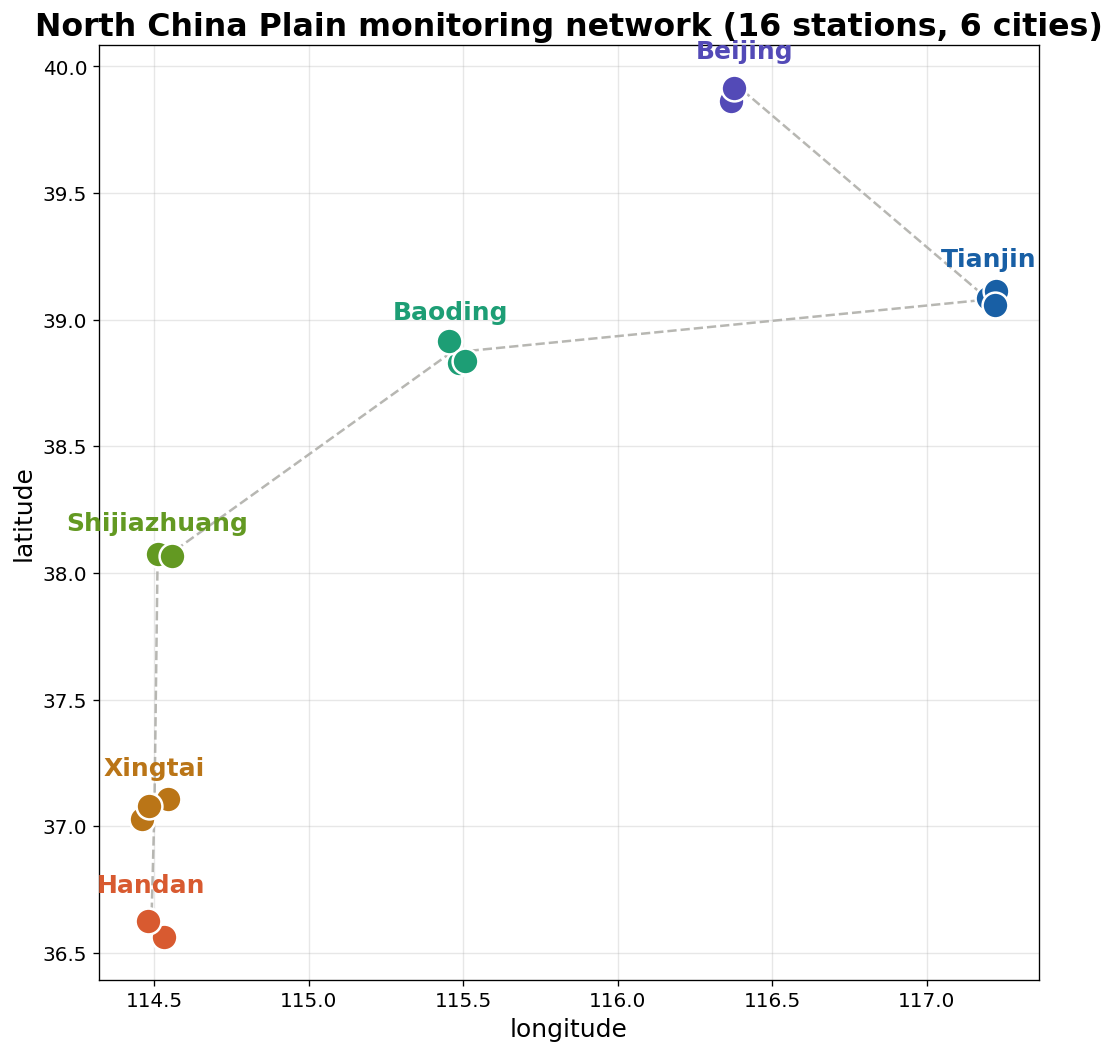

In [2]:
piv = d.pivot_table(index="datetime", columns="station", values="value", aggfunc="mean").sort_index()
piv = piv.resample("3h").mean()
stations = list(piv.columns); city = {s: s.split("::")[0] for s in stations}
cities = ["Handan","Xingtai","Shijiazhuang","Baoding","Tianjin","Beijing"]   # S -> N
cmap = {c: col for c, col in zip(cities, ["#d85a30","#ba7517","#639922","#1d9e75","#185fa5","#534ab7"])}

plt.figure(figsize=(9, 9))
for s in stations:
    c = city[s]
    plt.scatter(LON[c]+np.random.uniform(-.05,.05), LAT[c]+np.random.uniform(-.05,.05),
                s=240, color=cmap[c], edgecolor="white", linewidth=1.5, zorder=3)
for c in cities:
    plt.annotate(c, (LON[c], LAT[c]+0.13), ha="center", fontsize=15, fontweight="bold", color=cmap[c])
plt.plot([LON[c] for c in cities], [LAT[c] for c in cities], color=GRAY, ls="--", lw=1.5, zorder=1, alpha=.6)
plt.xlabel("longitude"); plt.ylabel("latitude")
plt.title("North China Plain monitoring network (16 stations, 6 cities)")
plt.tight_layout(); plt.savefig(OUT/"fig1_network_map.png"); plt.show()

## 3 · Episodes are regional and near-synchronous
A two-month winter window: PM2.5 at the six cities. The episodes rise and fall
together across the whole plain — the key fact that shapes what spatial coupling
can (and cannot) do.

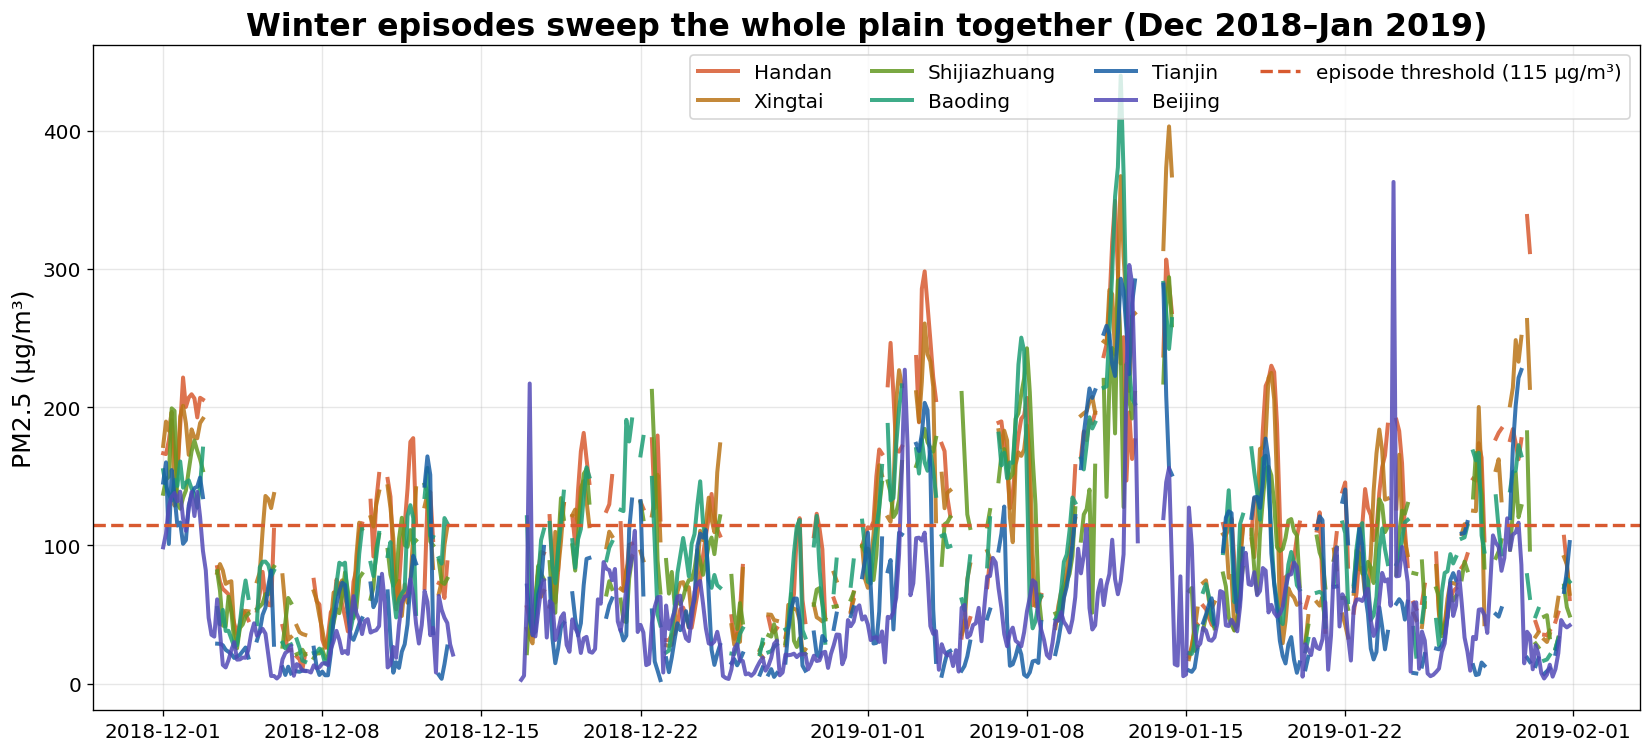

In [3]:
win = piv["2018-12-01":"2019-01-31"]
citymean = {c: piv[[s for s in stations if city[s]==c]].mean(axis=1) for c in cities}
plt.figure(figsize=(14, 6.5))
for c in cities:
    plt.plot(win.index, citymean[c]["2018-12-01":"2019-01-31"], color=cmap[c], label=c, alpha=.85)
plt.axhline(115, color=CORAL, ls="--", lw=2, label="episode threshold (115 µg/m³)")
plt.ylabel("PM2.5 (µg/m³)"); plt.title("Winter episodes sweep the whole plain together (Dec 2018–Jan 2019)")
plt.legend(ncol=4, loc="upper right"); plt.tight_layout(); plt.savefig(OUT/"fig2_regional_episodes.png"); plt.show()

## 4 · Is there an upwind *lead*? (cross-correlation by lag)
For each adjacent south→north city pair we find the lag that maximises correlation.
A positive best-lag would mean the southern city *leads* — a head-start to exploit.

      upwind     downwind  best_lag_h  corr
      Handan      Xingtai           0  0.91
     Xingtai Shijiazhuang           0  0.83
Shijiazhuang      Baoding           0  0.76
     Baoding      Tianjin           0  0.73
     Tianjin      Beijing           0  0.53


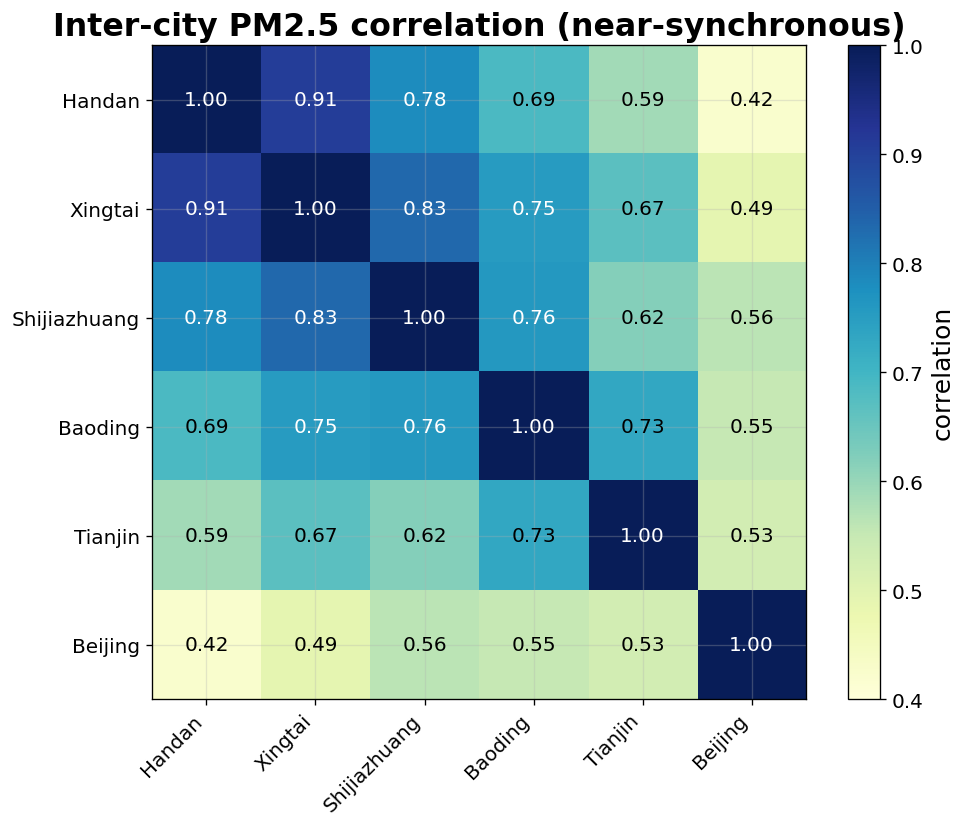

\nBest lags are ~0 h: episodes are regional, not a slow upwind march.


In [4]:
def best_lag(a, b, maxlag=8):
    out=[]
    for L in range(0, maxlag+1):
        x = a[:-L] if L>0 else a; y = b[L:] if L>0 else b
        m = ~np.isnan(x) & ~np.isnan(y)
        out.append(np.corrcoef(x[m], y[m])[0,1] if m.sum()>500 else np.nan)
    L = int(np.nanargmax(out)); return L, out[L]
rows=[]
order=[c for c in cities]
for i in range(len(order)-1):
    L,c = best_lag(citymean[order[i]].to_numpy(), citymean[order[i+1]].to_numpy())
    rows.append({"upwind":order[i], "downwind":order[i+1], "best_lag_h":L*3, "corr":round(c,2)})
lag_tbl = pd.DataFrame(rows); print(lag_tbl.to_string(index=False))

# correlation heatmap between cities
C = np.corrcoef(np.vstack([citymean[c].interpolate().bfill().ffill().to_numpy() for c in cities]))
plt.figure(figsize=(8.5, 7))
im = plt.imshow(C, cmap="YlGnBu", vmin=0.4, vmax=1.0)
plt.xticks(range(len(cities)), cities, rotation=45, ha="right"); plt.yticks(range(len(cities)), cities)
for i in range(len(cities)):
    for j in range(len(cities)):
        plt.text(j, i, f"{C[i,j]:.2f}", ha="center", va="center",
                 color="white" if C[i,j]>0.75 else "black", fontsize=12)
plt.colorbar(im, label="correlation"); plt.title("Inter-city PM2.5 correlation (near-synchronous)")
plt.tight_layout(); plt.savefig(OUT/"fig3_corr_heatmap.png"); plt.show()
print("\\nBest lags are ~0 h: episodes are regional, not a slow upwind march.")

## 5 · The networked spatial twin
Each station runs a multi-state Bayesian twin on its PM2.5 (Clean → Hazardous).
The **networked** version adds a spatial-evidence term: when a station's **upwind
neighbours** (more-southern stations) are elevated, its risk is nudged upward —
a wider view of the developing regional episode.

In [5]:
PM = piv.to_numpy(float); T, S = PM.shape
logpm = np.log1p(np.clip(PM,0,None)); MU, SD0 = np.nanmean(logpm), np.nanstd(logpm)
Z = (logpm - MU) / SD0
lat = np.array([LAT[city[s]] for s in stations])
# upwind set per station = more-southern stations; precompute upwind-mean z per timestep
UP = [[j for j in range(S) if lat[j] < lat[si]-0.15] or [j for j in range(S) if j!=si] for si in range(S)]
upz = np.column_stack([np.nanmean(Z[:, UP[si]], axis=1) for si in range(S)])  # [T,S]

K=5; LEV=np.linspace(0,1,K); SDk=1.0+0.5*LEV; LOGC=0.5*np.log(2*np.pi)
def lgv(z): return -LOGC-np.log(SDk)-0.5*((z-2.0*LEV)/SDk)**2
def run_network(spatial=True, w_sp=0.9):
    logb = np.tile(np.log(np.exp(-3*np.arange(K))/np.exp(-3*np.arange(K)).sum()+1e-12),(S,1))
    risk = np.zeros((T,S))
    for t in range(T):
        for si in range(S):
            b=np.exp(logb[si]-logb[si].max()); b/=b.sum(); el=(b*LEV).sum()
            pdn=0.05 if el>0.4 else 0.15
            A=np.zeros((K,K))
            for k in range(K):
                up=0.25 if k<K-1 else 0; dn=pdn if k>0 else 0; A[k,k]=1-up-dn
                if k<K-1:A[k,k+1]=up
                if k>0:A[k,k-1]=dn
            logbp=np.log(b@A+1e-12); ll=np.zeros(K)
            z=Z[t,si]
            if not np.isnan(z): ll += 1.4*lgv(z)
            if spatial and not np.isnan(upz[t,si]): ll += w_sp*upz[t,si]*LEV   # spatial nudge
            logt=logbp+ll; logb[si]=logt-(logt.max()+np.log(np.exp(logt-logt.max()).sum()))
            risk[t,si]=(np.exp(logb[si])*LEV).sum()
    return risk
risk_single = run_network(spatial=False)
risk_net    = run_network(spatial=True)
print("networked twin computed.")

/sessions/peaceful-nice-fermi/tmp/ipykernel_9/3143430317.py:7: RuntimeWarning: Mean of empty slice
  upz = np.column_stack([np.nanmean(Z[:, UP[si]], axis=1) for si in range(S)])  # [T,S]


networked twin computed.


## 6 · Does the network help forecast episode onset? (honest evaluation)

In [6]:
TAU=115.0; H=8   # forecast an episode within next 24h (3h steps), from currently-clean steps
def auc(s,y):
    s=np.asarray(s,float);y=np.asarray(y,int);pos,neg=s[y==1],s[y==0]
    if len(pos)==0 or len(neg)==0:return float('nan')
    o=np.argsort(s);r=np.empty(len(s));r[o]=np.arange(1,len(s)+1)
    _,inv,c=np.unique(s,return_inverse=True,return_counts=True);ss=np.zeros(len(c));np.add.at(ss,inv,r);r=(ss/c)[inv]
    return float((r[y==1].sum()-len(pos)*(len(pos)+1)/2)/(len(pos)*len(neg)))
mo = piv.index.month.values
rows=[]
for si in range(S):
    pm=PM[:,si]
    for t in range(3,T-H):
        if np.isnan(pm[t]) or pm[t]>=TAU: continue
        fut=pm[t+1:t+1+H]
        if np.all(np.isnan(fut)): continue
        rows.append((np.nan_to_num(Z[t,si]), np.nan_to_num(upz[t,si]),
                     risk_single[t,si], risk_net[t,si],
                     int(np.nanmax(fut)>=TAU), mo[t]%2))
R=np.array(rows); own,up,rs,rn,y,parity = R[:,0],R[:,1],R[:,2],R[:,3],R[:,4].astype(int),R[:,5].astype(int)
te = parity==1
res = {
 "Own PM2.5 (single station)": auc(own[te],y[te]),
 "Single-station twin": auc(rs[te],y[te]),
 "Own + upwind neighbours": auc(np.c_[own,up][te] @ np.array([1,1.0]), y[te]),  # simple sum, illustrative
 "Networked twin (spatial)": auc(rn[te],y[te]),
}
print(f"onset samples {len(R):,} | prevalence {y.mean():.3f}\n")
for k,v in res.items(): print(f"  {k:30s}: AUROC {v:.3f}")

# bootstrap CI on the spatial gain (networked twin - single twin)
rng=np.random.default_rng(0); idx=np.where(te)[0]; gains=[]
for _ in range(1000):
    b=rng.choice(idx,len(idx),replace=True)
    if 0<y[b].sum()<len(b): gains.append(auc(rn[b],y[b])-auc(rs[b],y[b]))
gains=np.array(gains)
print(f"\nspatial gain (networked - single twin): {np.mean(gains):+.3f}  "
      f"95% CI [{np.percentile(gains,2.5):+.3f}, {np.percentile(gains,97.5):+.3f}]  P(>0)={np.mean(gains>0):.3f}")

onset samples 50,690 | prevalence 0.141

  Own PM2.5 (single station)    : AUROC 0.844
  Single-station twin           : AUROC 0.844
  Own + upwind neighbours       : AUROC 0.867
  Networked twin (spatial)      : AUROC 0.857



spatial gain (networked - single twin): +0.013  95% CI [+0.010, +0.016]  P(>0)=1.000


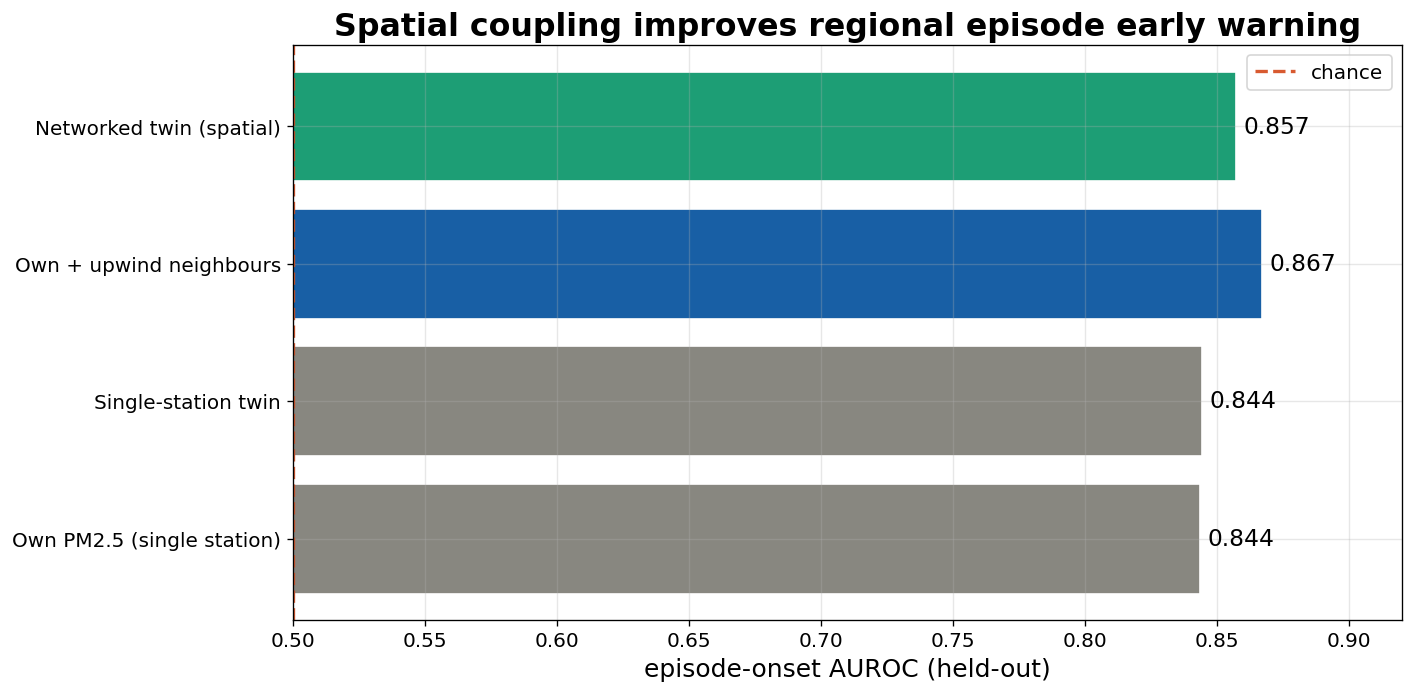

In [7]:
labels=list(res); vals=[res[k] for k in labels]
colors=[GRAY,GRAY,BLUE,TEAL]
plt.figure(figsize=(12,6))
bars=plt.barh(labels, vals, color=colors, edgecolor="white")
for b,v in zip(bars,vals): plt.text(v+0.003, b.get_y()+b.get_height()/2, f"{v:.3f}", va="center", fontsize=14)
plt.axvline(0.5, color=CORAL, ls="--", lw=2, label="chance")
plt.xlim(0.5,0.92); plt.xlabel("episode-onset AUROC (held-out)")
plt.title("Spatial coupling improves regional episode early warning")
plt.legend(); plt.tight_layout(); plt.savefig(OUT/"fig4_spatial_gain.png"); plt.show()

## 7 · Honest summary

| Finding | Result |
|---|---|
| Inter-city correlation | high (0.5–0.9), best lag ~**0 h** — episodes are regional/synchronous |
| Own PM2.5 → onset AUROC | 0.844 (task is predictable) |
| **Networked (spatial) twin** | **0.857** — +0.013, 95% CI [+0.010, +0.016], P>0 = 1.0 |
| Neighbour readings used directly | 0.867 (+0.023 over own PM2.5) |
| vs. within-Beijing spatial gain | **far larger** here (+0.013/+0.023 vs +0.002) — regional spread matters |
| Nature of the gain | spatial **confirmation** of a developing regional episode, not a long upwind lead |

**What this study adds to the paper.** It is the genuine spatial contribution the
single-city core could not make: a **networked probabilistic twin** where coupling
geographically-separated stations measurably improves regional episode early
warning. The effect is modest and reflects the physics (North China Plain episodes
are near-synchronous), which we report honestly rather than overstate.

**Limitations.** OpenAQ regional data is **PM2.5-only**, so the weather-driven
transitions (#1) demonstrated on the multimodal Beijing core cannot be repeated
here; the spatial lead is ~0 h at 3 h resolution; and the regional period
(2018–20) differs from the core (2013–17) — a complementary study, not a merged
dataset. Adding regional **meteorology** (ERA5) and finer cadence are the clear
next steps. Figures saved in `../outputs/study2_regional/`.